# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
from cross_sections import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', 20)

### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [2]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

### Provide the directory for saving results

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\01_operando"

### Provide the directory freference measurements (this is a special case)

In [118]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000_chopped\pre_oper20C"

## Operation 20C

### To transmission images

In [5]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000_chopped\01_LP30_oper_20C_15min_avg"

### Set the ROIs to analyze

In [52]:
src_dict = read_saved_dict (src_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 1/1 [00:01<00:00,  1.18s/it]


In [119]:
ref_dict = read_saved_dict (ref_dir, proc_folder = ['10_pos04'])

Reading Images: 100%|████████████████████████████| 1/1 [00:02<00:00,  2.18s/it]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in src_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 degraded
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_08_pos03 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_12_pos05 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_14_pos06 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_16_pos07 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_18_pos08 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_20_pos09 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

In [ ]:
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

ROIs_02_pos00


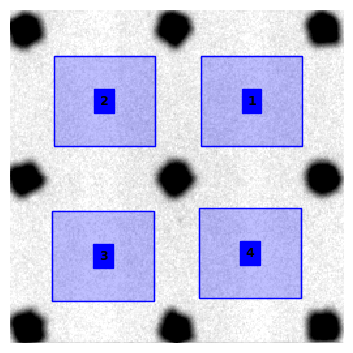

ROIs_04_pos01


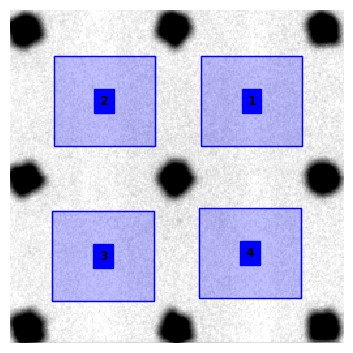

ROIs_06_pos02


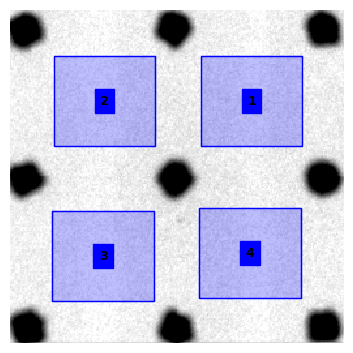

ROIs_08_pos03


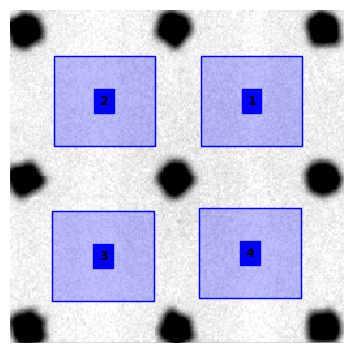

ROIs_10_pos04


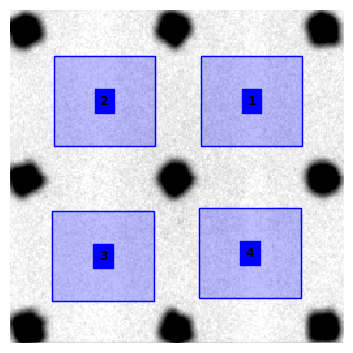

ROIs_12_pos05


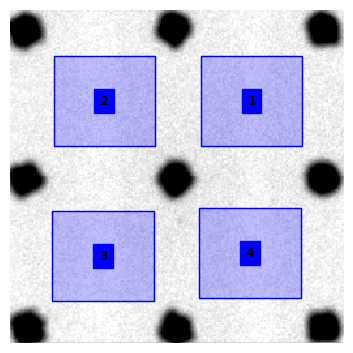

ROIs_14_pos06


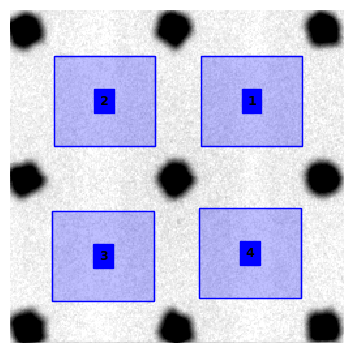

ROIs_16_pos07


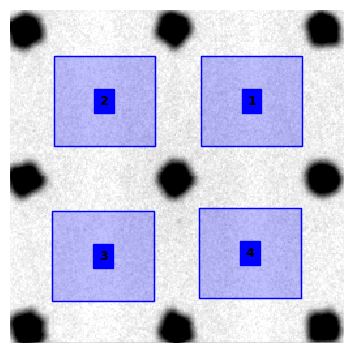

ROIs_18_pos08


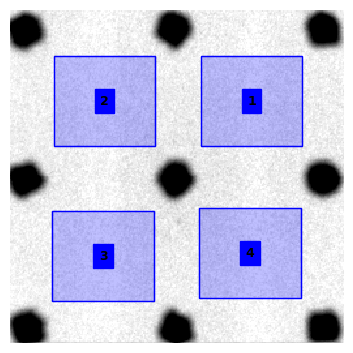

ROIs_20_pos09


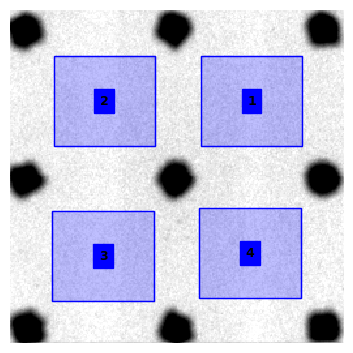

In [9]:
idx = 1
for name in src_dict.keys():
    rois_name = 'ROIs_'+ name
    print(rois_name)
    show_img(avg_imgs[idx-1], dr = [(eval(rois_name), 'blue')], cmap='gray', nrows=5, ncols=2, index=idx)
    idx+=1

#### Create a dictionary of the ROIs

In [120]:
rois_dict = {}
for name in src_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [121]:
ref_rois_dict = {}
rois_name = 'ROIs_10_pos04'
for n in range(10):
    ref_rois_dict[rois_name] = eval(rois_name)

### Extract the values

**NOTE: here `get_roi_values_acq` takes into account that there was a acquisitions binning. This case is special for taking only 15 min instead of the 30 min of exposure**


In [122]:
img_vals = get_roi_values_acqs (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = 56, start_slice = 334, end_slice = 626, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, ref_rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = 56, start_slice = 334, end_slice = 626, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

**This is a quick fix to get the same positions and rois corresponding to those in the operando experiment**

In [123]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = pd.DataFrame()

for name in src_dict.keys():
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx) + '_acq0'
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx) ]
    
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx) + '_acq1'
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx) ]
        
new_ref_vals = pd.concat([data_wvl,new_ref_vals], axis = 1)

In [124]:
img_vals

,Wavelength [Å],Values_02_pos00_roi_1_acq0,Values_02_pos00_roi_2_acq0,Values_02_pos00_roi_3_acq0,Values_02_pos00_roi_4_acq0,Values_02_pos00_roi_1_acq1,Values_02_pos00_roi_2_acq1,Values_02_pos00_roi_3_acq1,Values_02_pos00_roi_4_acq1,Values_04_pos01_roi_1_acq0,...,Values_18_pos08_roi_3_acq1,Values_18_pos08_roi_4_acq1,Values_20_pos09_roi_1_acq0,Values_20_pos09_roi_2_acq0,Values_20_pos09_roi_3_acq0,Values_20_pos09_roi_4_acq0,Values_20_pos09_roi_1_acq1,Values_20_pos09_roi_2_acq1,Values_20_pos09_roi_3_acq1,Values_20_pos09_roi_4_acq1
0,5.007929,0.872142,0.875872,0.883705,0.875409,0.866214,0.874822,0.882390,0.881713,0.863033,...,0.884672,0.875238,0.869031,0.865041,0.874720,0.875287,0.866256,0.867506,0.874553,0.870764
1,5.019508,0.842115,0.849963,0.860565,0.847565,0.868285,0.860733,0.874282,0.870878,0.847873,...,0.865597,0.864964,0.856846,0.866383,0.869152,0.852783,0.859176,0.862794,0.870316,0.858422
2,5.031079,0.842091,0.843309,0.857954,0.853541,0.848472,0.851349,0.859192,0.854663,0.843104,...,0.862465,0.850700,0.845318,0.853363,0.850008,0.855689,0.848942,0.850207,0.854405,0.850247
3,5.042658,0.837689,0.846177,0.844054,0.847338,0.846944,0.846163,0.847540,0.851041,0.833986,...,0.848503,0.847400,0.835807,0.843909,0.849208,0.848083,0.836924,0.838560,0.850330,0.844748
4,5.054229,0.833474,0.832423,0.836411,0.839542,0.831848,0.829434,0.837224,0.833148,0.825080,...,0.838888,0.838201,0.824656,0.818658,0.841196,0.841294,0.834084,0.849434,0.841196,0.842069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,8.455034,0.037585,0.040654,0.035944,0.037589,0.034130,0.038631,0.036771,0.034283,0.031961,...,0.040891,0.036724,0.034362,0.037490,0.036597,0.036628,0.036424,0.036810,0.039159,0.038015
288,8.466619,0.032652,0.038325,0.038761,0.033878,0.031565,0.039613,0.038476,0.035507,0.038377,...,0.038370,0.036928,0.034789,0.039353,0.040693,0.037226,0.034375,0.041618,0.038887,0.039202
289,8.478205,0.032165,0.038428,0.042124,0.034748,0.033695,0.038861,0.038497,0.034920,0.034654,...,0.036631,0.035423,0.035291,0.039662,0.038913,0.036296,0.037113,0.042242,0.038717,0.037462
290,8.489790,0.034001,0.038033,0.034878,0.035280,0.034806,0.038181,0.038526,0.036124,0.033767,...,0.033005,0.034628,0.036973,0.037971,0.036142,0.035404,0.036520,0.038166,0.039040,0.037637


In [125]:
new_ref_vals

,Wavelength [Å],Values_02_pos00_roi_1_acq0,Values_02_pos00_roi_2_acq0,Values_02_pos00_roi_3_acq0,Values_02_pos00_roi_4_acq0,Values_02_pos00_roi_1_acq1,Values_02_pos00_roi_2_acq1,Values_02_pos00_roi_3_acq1,Values_02_pos00_roi_4_acq1,Values_04_pos01_roi_1_acq0,...,Values_18_pos08_roi_3_acq1,Values_18_pos08_roi_4_acq1,Values_20_pos09_roi_1_acq0,Values_20_pos09_roi_2_acq0,Values_20_pos09_roi_3_acq0,Values_20_pos09_roi_4_acq0,Values_20_pos09_roi_1_acq1,Values_20_pos09_roi_2_acq1,Values_20_pos09_roi_3_acq1,Values_20_pos09_roi_4_acq1
0,5.007929,0.862508,0.870373,0.878843,0.865269,0.862508,0.870373,0.878843,0.865269,0.862508,...,0.878843,0.865269,0.862508,0.870373,0.878843,0.865269,0.862508,0.870373,0.878843,0.865269
1,5.019508,0.856362,0.854817,0.868264,0.854264,0.856362,0.854817,0.868264,0.854264,0.856362,...,0.868264,0.854264,0.856362,0.854817,0.868264,0.854264,0.856362,0.854817,0.868264,0.854264
2,5.031079,0.844529,0.851243,0.859540,0.852294,0.844529,0.851243,0.859540,0.852294,0.844529,...,0.859540,0.852294,0.844529,0.851243,0.859540,0.852294,0.844529,0.851243,0.859540,0.852294
3,5.042658,0.836552,0.842533,0.852557,0.841975,0.836552,0.842533,0.852557,0.841975,0.836552,...,0.852557,0.841975,0.836552,0.842533,0.852557,0.841975,0.836552,0.842533,0.852557,0.841975
4,5.054229,0.831610,0.840123,0.843041,0.836603,0.831610,0.840123,0.843041,0.836603,0.831610,...,0.843041,0.836603,0.831610,0.840123,0.843041,0.836603,0.831610,0.840123,0.843041,0.836603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,8.455034,0.034278,0.037601,0.038523,0.033904,0.034278,0.037601,0.038523,0.033904,0.034278,...,0.038523,0.033904,0.034278,0.037601,0.038523,0.033904,0.034278,0.037601,0.038523,0.033904
288,8.466619,0.034363,0.038753,0.038137,0.034345,0.034363,0.038753,0.038137,0.034345,0.034363,...,0.038137,0.034345,0.034363,0.038753,0.038137,0.034345,0.034363,0.038753,0.038137,0.034345
289,8.478205,0.034340,0.038316,0.036129,0.034922,0.034340,0.038316,0.036129,0.034922,0.034340,...,0.036129,0.034922,0.034340,0.038316,0.036129,0.034922,0.034340,0.038316,0.036129,0.034922
290,8.489790,0.031488,0.036192,0.036424,0.033788,0.031488,0.036192,0.036424,0.033788,0.031488,...,0.036424,0.033788,0.031488,0.036192,0.036424,0.033788,0.031488,0.036192,0.036424,0.033788


In [126]:
trans_rois = prepare_trans_data(img_vals, data_ref = new_ref_vals, data_output = 'transmission')

In [127]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1_acq0,Transmission_02_pos00_roi_2_acq0,Transmission_02_pos00_roi_3_acq0,Transmission_02_pos00_roi_4_acq0,Transmission_02_pos00_roi_1_acq1,Transmission_02_pos00_roi_2_acq1,Transmission_02_pos00_roi_3_acq1,Transmission_02_pos00_roi_4_acq1,Transmission_04_pos01_roi_1_acq0,...,Transmission_18_pos08_roi_3_acq1,Transmission_18_pos08_roi_4_acq1,Transmission_20_pos09_roi_1_acq0,Transmission_20_pos09_roi_2_acq0,Transmission_20_pos09_roi_3_acq0,Transmission_20_pos09_roi_4_acq0,Transmission_20_pos09_roi_1_acq1,Transmission_20_pos09_roi_2_acq1,Transmission_20_pos09_roi_3_acq1,Transmission_20_pos09_roi_4_acq1
0,5.007929,1.011171,1.006318,1.005532,1.011719,1.004298,1.005112,1.004036,1.019005,1.000609,...,1.006632,1.011521,1.007564,0.993873,0.995309,1.011578,1.004346,0.996706,0.995119,1.006351
1,5.019508,0.983364,0.994321,0.991132,0.992159,1.013923,1.006920,1.006931,1.019449,0.990088,...,0.996928,1.012526,1.000565,1.013530,1.001022,0.998267,1.003287,1.009332,1.002363,1.004868
2,5.031079,0.997112,0.990680,0.998155,1.001463,1.004669,1.000125,0.999595,1.002780,0.998312,...,1.003404,0.998129,1.000934,1.002490,0.988911,1.003984,1.005225,0.998783,0.994026,0.997599
3,5.042658,1.001358,1.004326,0.990027,1.006369,1.012422,1.004309,0.994115,1.010766,0.996932,...,0.995245,1.006442,0.999109,1.001634,0.996072,1.007254,1.000445,0.995284,0.997388,1.003293
4,5.054229,1.002241,0.990834,0.992136,1.003512,1.000286,0.987277,0.993100,0.995870,0.992148,...,0.995073,1.001910,0.991638,0.974450,0.997811,1.005607,1.002975,1.011083,0.997812,1.006533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,8.455034,1.096465,1.081197,0.933063,1.108679,0.995672,1.027403,0.954517,1.011188,0.932405,...,1.061483,1.083170,1.002447,0.997048,0.950001,1.080337,1.062602,0.978973,1.016516,1.121246
288,8.466619,0.950220,0.988966,1.016351,0.986403,0.918573,1.022205,1.008893,1.033840,1.116799,...,1.006101,1.075193,1.012398,1.015497,1.067022,1.083894,1.000360,1.073948,1.019660,1.141424
289,8.478205,0.936653,1.002922,1.165938,0.995015,0.981203,1.014200,1.065536,0.999925,1.009157,...,1.013880,1.014327,1.027696,1.035107,1.077051,1.039329,1.080744,1.102455,1.071628,1.072712
290,8.489790,1.079811,1.050863,0.957540,1.044171,1.105394,1.054954,1.057696,1.069141,1.072370,...,0.906113,1.024875,1.174208,1.049140,0.992256,1.047822,1.159826,1.054539,1.071807,1.113917


In [14]:
save_DF (dst_dir, img_vals, df_name = '00_insitu_20C_cropped_trans.xlsx', sheet_name = 'oper_20C_15_min_int', mode = 'w')

In [29]:
save_DF (dst_dir, new_ref_vals, df_name = '00_insitu_20C_cropped_trans.xlsx', sheet_name = 'after_oper', mode = 'a')

### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [128]:
res_data = dataframe_to_savgol(trans_rois, 21, 2)

In [129]:
#save_DF (dst_dir, res_data, df_name = '00_insitu_20C_H_CS.xlsx', sheet_name = 'oper_20C_15_min', mode = 'a')

In [130]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
pos05 = [column for column in res_data if 'pos05' in column]
pos06 = [column for column in res_data if 'pos06' in column]
pos07 = [column for column in res_data if 'pos07' in column]
pos08 = [column for column in res_data if 'pos08' in column]
pos09 = [column for column in res_data if 'pos09' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)
cs_pos05_dat = pd.concat([data_wvl, res_data[pos05]], axis = 1)
cs_pos06_dat = pd.concat([data_wvl, res_data[pos06]], axis = 1)
cs_pos07_dat = pd.concat([data_wvl, res_data[pos07]], axis = 1)
cs_pos08_dat = pd.concat([data_wvl, res_data[pos08]], axis = 1)
cs_pos09_dat = pd.concat([data_wvl, res_data[pos09]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos05'] = cs_pos05_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos06'] = cs_pos06_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos07'] = cs_pos07_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos08'] = cs_pos08_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos09'] = cs_pos09_dat.iloc[:,1:].mean(axis=1)

In [131]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos05_dat=cs_pos05_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos06_dat=cs_pos06_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos07_dat=cs_pos07_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos08_dat=cs_pos08_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos09_dat=cs_pos09_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [132]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

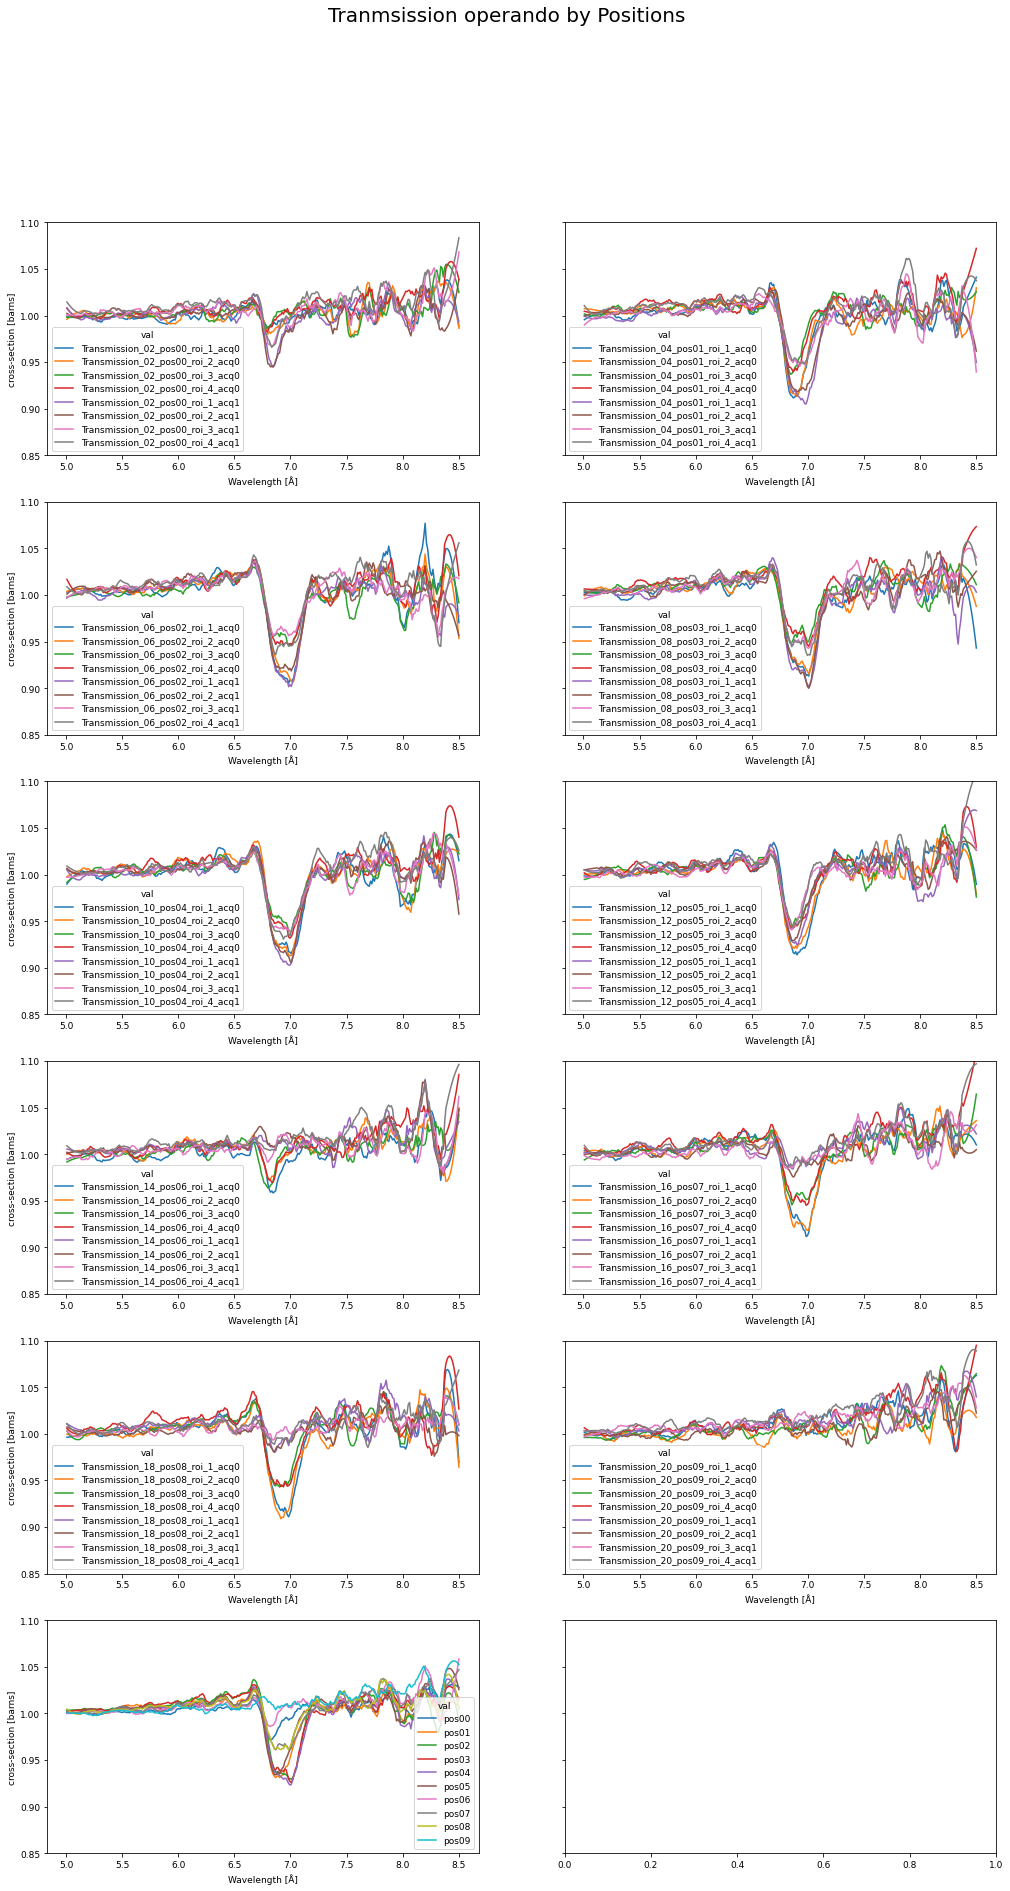

In [134]:
fig0, ax = plt.subplots(6,2, figsize = (17,30), sharey = True)
fig0.suptitle('Tranmsission operando by Positions', fontsize = 20)
#plt.ylim([0.6,0.8])
plt.ylim([0.85,1.1])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = cs_pos05_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[3,0], data = cs_pos06_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[3,1], data = cs_pos07_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[4,0], data = cs_pos08_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[4,1], data = cs_pos09_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[5,0], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')